# Dataset cortes de tráfico

Este notebook analiza el dataset de cortes de tráfico de Chicago (`Transportation_Department_Permits_-_Street_Closures_20260801.csv`).

**Información del dataset:**

Los datos muestran registros relacionados con cualquier tipo de cierre de vías (por obras, eventos, etc.) bajo el Departamento de Transporte de Chicago.

- Metadata:

| Propietario |  Período | Frecuencia |
|---|---|---|
|Departamento de Transporte de Chicago | 2015 - actualidad| Diario|

## 0. Importación de paquetes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap

from EDA_general import *

## 1. EDA

### 1.1. Carga y visión general

In [3]:
df = pd.read_csv("data/Transportation_Department_Permits_-_Street_Closures_20260801.csv", low_memory=False)

In [4]:
resumen_general(df)

Dimensiones: 466,806 filas x 46 columnas

Tipos de dato por columna:
UNIQUEKEY                         int64
APPLICATIONNUMBER                   str
APPLICATIONTYPE                     str
APPLICATIONDESCRIPTION              str
WORKTYPE                            str
WORKTYPEDESCRIPTION                 str
APPLICATIONSTATUS                   str
CURRENTMILESTONE                    str
APPLICATIONSTARTDATE                str
APPLICATIONENDDATE                  str
APPLICATIONPROCESSEDDATE            str
APPLICATIONISSUEDDATE               str
APPLICATIONFINALIZEDDATE            str
APPLICATIONEXPIREDATE               str
APPLICATIONNAME                     str
COMMENTS                            str
TOTALFEES                           str
WAIVEDFEES                          str
PRIMARYCONTACTLAST                  str
PRIMARYCONTACTFIRST                 str
PRIMARYCONTACTMIDDLE                str
PRIMARYCONTACTSTREET                str
PRIMARYCONTACTSTREET2               str
PRIMARYCONT

El dataset contiene **466.806 filas y 46 columnas**. La mayoría de columnas son de gestión del permiso (fechas de tramitación, tasas, datos de contacto...) que no aportan nada
para el proyecto.

### 1.2. Calidad de los datos

In [5]:
calidad_datos(df, id_col="UNIQUEKEY")

Valores nulos por columna:
                               nulos  % nulos
PLACEMENT                     466806   100.00
PRIMARYCONTACTMIDDLE          466501    99.93
LASTINSPTYPEDESCR             448050    95.98
LASTINSPECTIONDATE            448050    95.98
LASTINSPECTIONTYPE            448050    95.98
LASTINSPECTIONNUMBER          448050    95.98
LASTINSPECTIONRESULT          448050    95.98
PRIMARYCONTACTSTREET2         441389    94.56
PARKINGMETERPOSTINGORBAGGING  429211    91.95
PRIMARYCONTACTFIRST           416614    89.25
APPLICATIONFINALIZEDDATE      387412    82.99
DETAIL                        275055    58.92
WAIVEDFEES                    134358    28.78
TOTALFEES                      78740    16.87
COMMENTS                       69274    14.84
APPLICATIONNAME                58611    12.56
APPLICATIONEXPIREDATE          25653     5.50
APPLICATIONISSUEDDATE          24398     5.23
PRIMARYCONTACTZIP              12918     2.77
APPLICATIONPROCESSEDDATE       10064     2.16
SUFFIX 

Hay un grupo de columnas que casi siempre son nulas (`PLACEMENT` al 100%, `PRIMARYCONTACTMIDDLE` al
99.9%, las de `LASTINSPECTION*` al ~96%...). Las eliminaremos todas.

Por otro lado, **0 duplicados** por `UNIQUEKEY`.

Por último, las variables `PRIMARYCONTACT*` y `EMERGENCYCONTACTNAME` son datos personales de quien solicitó el permiso (nombre, dirección, contacto de emergencia). No aportan nada al trabajo, así que las eliminaremos.

### 1.3. Análisis temporal

Fechas que no se pudieron parsear: 286
Rango de fechas: 1994-06-27 00:00:00 -> 2112-08-25 00:00:00


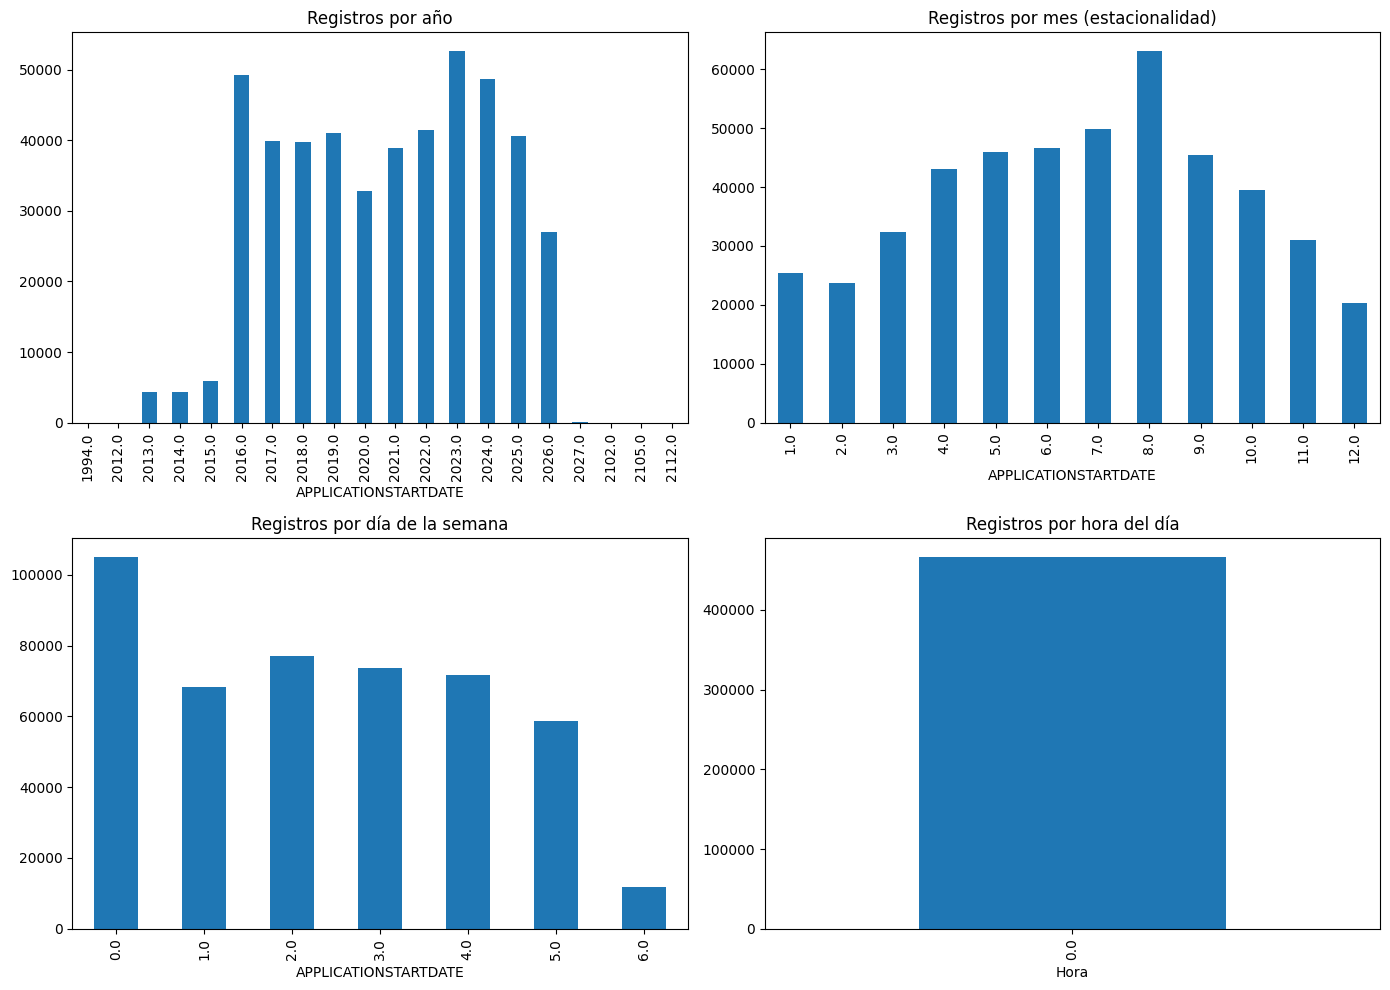

In [6]:
# formato de date: "08/22/2023"
df["start_date"] = analisis_temporal(df, date_col="APPLICATIONSTARTDATE", date_format="%m/%d/%Y", evento="Registros")

Si nos fijamos en el rango de fechas, sale el máximo en **2112**, cosa que es imposible. Asique vamos a ver cuantas filas hay con fecha mayor a 2027, ya que no nos interesan.

In [7]:
df["APPLICATIONSTARTDATE"] = pd.to_datetime(df["APPLICATIONSTARTDATE"], errors="coerce")
n_fechas = (df["APPLICATIONSTARTDATE"].dt.year > 2027).sum()

print(f"Hay {n_fechas} filas con año mayor que 2027.")

Hay 6 filas con año mayor que 2027.


Hay 6 filas, que sobre
casi 467,000 filas es un porcentaje muy bajo, así que en la limpieza las vamos a descartar filtrando por un rango de años razonable (2012–2027, que es donde está el grueso de los datos).

Quitando esas filas, el dataset va de 2012 a 2026 más o menos de forma continua, con un pico en 2016 y una bajada notable en 2020 (lógico por la pandemia, menos obras y eventos en la calle
ese año).

In [8]:
# duración de cada cierre, para hacernos una idea de cuánto tiempo suele
# estar una calle afectada
df["end_date"] = pd.to_datetime(df["APPLICATIONENDDATE"], format="%m/%d/%Y", errors="coerce")
duracion = (df["end_date"] - df["start_date"]).dt.days

print(duracion.describe())

print("\nDuración mediana (días) por tipo de obra:")
print(pd.DataFrame({"duracion": duracion, "tipo": df["WORKTYPEDESCRIPTION"]})
      .groupby("tipo")["duracion"].median().sort_values())

count    466520.000000
mean         45.331797
std          83.263136
min           0.000000
25%          23.000000
50%          29.000000
75%          30.000000
max       28124.000000
dtype: float64

Duración mediana (días) por tipo de obra:
tipo
Assembly                                                                 0.0
Sidewalk Sale                                                            0.0
Parade                                                                   0.0
Make Way for People Program                                              0.0
Media Parking                                                            0.0
Block Party                                                              0.0
Athletic                                                                 0.0
Festival                                                                 1.0
Filming                                                                  1.0
Maintenance                                                 

La mediana de duración es de **29 días**, pero varía mucho según el tipo de obra: eventos puntuales como `Block Party`, `Parade` o `Assembly`
duran 0 días (el mismo día), mientras que `Opening in the Public Way` o `Restoration` rondan el mes, y `Farmer's Market` sale con 147 días de
mediana.

Con esto concluimos que no todos los cierres afectan igual a una ruta de reparto.

### 1.4. Análisis geográfico

Antes de nada, `LATITUDE`/`LONGITUDE` vienen con coma decimal en vez de
punto (`"41,9741516462"` en vez de `"41.9741516462"`). Lo arreglamos antes de
tratarlas como número.

In [ ]:
# arreglamos la coma decimal antes de convertir a número
df["lat_num"] = pd.to_numeric(df["LATITUDE"].str.replace(",", ".", regex=False), errors="coerce")
df["lon_num"] = pd.to_numeric(df["LONGITUDE"].str.replace(",", ".", regex=False), errors="coerce")

analisis_geografico(df, lat_col="lat_num", lon_col="lon_num", mostrar_heatmap=True)

Solo un 0.1% de filas estan sin coordenadas (261 de 466,806), así que las eliminamos en la limpieza.

En el heatmap se ve que las obras se almacenan en las vias más importantes de la
ciudad, no están repartidas de forma uniforme.

### 1.5. Tipo de cierre

In [10]:
print("Distribución de STREETCLOSURE:")
print(df["STREETCLOSURE"].value_counts(dropna=False))

Distribución de STREETCLOSURE:
STREETCLOSURE
Curblane      248288
Full           98385
Sidewalk       77854
Partial        41764
Intermitte       515
Name: count, dtype: int64


La variable viene bastante bien categorizada, con 5
valores diferentes:

- `Curblane` (248,288) — solo se corta un carril lateral, es el más habitual.
- `Full` (98,385) — corte completo de la calle, es el más grave para una ruta.
- `Sidewalk` (77,854) — solo acera, no afecta a vehículos.
- `Partial` (41,764) — corte parcial.
- `Intermitte` (515) — cortes intermitentes, un caso muy minoritario.

Por lo tanto vamos a borrar la filas donde `STREETCLOSURE` sea `Sidewalk`, ya que no afecta al tráfico.

### 1.6. Análisis por calle

In [11]:
analisis_calles(df, street_col="STREETNAME", dir_col="DIRECTION")

Top 15 'STREETNAME' con más registros:
STREETNAME
WESTERN       3560
ASHLAND       3332
CLARK         2806
HALSTED       2737
MICHIGAN      2520
DAMEN         2502
PAULINA       2501
KEDZIE        2362
STATE         2341
OAKLEY        2306
CAMPBELL      2276
CALIFORNIA    2207
HOYNE         2168
WASHTENAW     2098
MILWAUKEE     2072
Name: count, dtype: int64

Distribución de DIRECTION:
DIRECTION
S    156839
W    153060
N    132429
E     24478
Name: count, dtype: int64


Las calles con más accidentes son avenidas grandes (Western,  Ashland...), lo que concuerda con el heatmap de antes.

## 2. Limpieza

**Columnas que nos interesan:**
- `APPLICATIONSTARTDATE`, `APPLICATIONENDDATE`: la ventana real en la que la calle está afectada.
- `LATITUDE`, `LONGITUDE`: cruce espacial con el resto de datasets.
- `STREETNAME`, `DIRECTION`, `SUFFIX`, `STREETNUMBERFROM`, `STREETNUMBERTO`: alternativa por calle si el cruce espacial falla.
- `STREETCLOSURE`: el impacto real del cierre (Full/Partial/Curblane/Intermitte).
- `UNIQUEKEY`: después lo borraremos.

Todo lo demás (datos de contacto, tasas, fechas administrativas del
trámite, inspecciones...) no nos interesa ya que no aportan nada al problema de rutas.

In [12]:
columnas = [
    "UNIQUEKEY",
    "APPLICATIONSTARTDATE", "APPLICATIONENDDATE",
    "LATITUDE", "LONGITUDE",
    "STREETNAME", "DIRECTION", "SUFFIX", "STREETNUMBERFROM", "STREETNUMBERTO",
    "STREETCLOSURE",
]
df = df[columnas].copy()
print(f"Tras seleccionar las columnas relevantes: {df.shape[1]} columnas")

Tras seleccionar las columnas relevantes: 11 columnas


### 2.1. Temporal

In [13]:
df["APPLICATIONSTARTDATE"] = pd.to_datetime(df["APPLICATIONSTARTDATE"], format="%m/%d/%Y", errors="coerce")
df["APPLICATIONENDDATE"] = pd.to_datetime(df["APPLICATIONENDDATE"], format="%m/%d/%Y", errors="coerce")

# quitamos filas sin fecha de inicio
df = df.dropna(subset=["APPLICATIONSTARTDATE"])

# quitamos las fechas raras que vimos en el EDA quedándonos con el rango real de los datos
rango_valido = df["APPLICATIONSTARTDATE"].dt.year.between(2012, 2027)
print(f"Filas descartadas por fecha fuera de rango razonable: {(~rango_valido).sum()}")
df = df[rango_valido]

df = df.sort_values("APPLICATIONSTARTDATE").reset_index(drop=True)

Filas descartadas por fecha fuera de rango razonable: 7


### 2.2. Geográfico

In [14]:
# arreglamos la coma decimal y convertimos a número
df["LATITUDE"] = pd.to_numeric(df["LATITUDE"].str.replace(",", ".", regex=False), errors="coerce")
df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"].str.replace(",", ".", regex=False), errors="coerce")

df = df.dropna(subset=["LATITUDE", "LONGITUDE"])

# normalizamos texto para el futuro cruce con otros datasets
for col in ["STREETNAME", "DIRECTION", "SUFFIX"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

### 2.3. Gravedad

In [15]:
# eliminamos las filas que en la columna STREETCLOSURE tengan
# como valor Sidewalk, ya que no afecta al tráfico
df = df[df["STREETCLOSURE"] != "Sidewalk"]

### 2.4. Quitamos el ID

In [16]:
# eliminamos UNIQUEKEY
df = df.drop(columns=["UNIQUEKEY"])

print(f"\nDataset final: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(df.head())


Dataset final: 388,421 filas x 10 columnas
  APPLICATIONSTARTDATE APPLICATIONENDDATE   LATITUDE  LONGITUDE   STREETNAME  \
0           2012-03-01         2013-03-01  41.753337 -87.549682  SOUTH SHORE   
1           2012-03-01         2013-03-01  41.755253 -87.551366  SOUTH SHORE   
2           2012-03-01         2013-03-01  41.752089 -87.547920         79TH   
3           2012-03-07         2013-02-28  41.657895 -87.559437     TORRENCE   
4           2012-03-07         2013-02-28  41.659126 -87.559433     TORRENCE   

  DIRECTION SUFFIX  STREETNUMBERFROM  STREETNUMBERTO STREETCLOSURE  
0         S     DR              7842            7899          Full  
1         S     DR              7801            7841          Full  
2         E     ST              3130            3199          Full  
3         S    AVE             13042           13199          Full  
4         S    AVE             13000           13041          Full  


El dataset final queda en: `APPLICATIONSTARTDATE`, `APPLICATIONENDDATE`,
`LATITUDE`, `LONGITUDE`, `STREETNAME`, `DIRECTION`, `SUFFIX`,
`STREETNUMBERFROM`, `STREETNUMBERTO`, `STREETCLOSURE`,
`WORKTYPEDESCRIPTION`.

In [19]:
# guardamos en un csv
df.to_csv("data_clean/closures.csv", index=False)